<a href="https://colab.research.google.com/github/samuspdf/PricePredictor/blob/main/PricePredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd

In [ ]:
#Importing data from yfinance of SPY

data = yf.download("SPY",start="2015-01-01",end="2025-01-01")


/tmp/ipykernel_1150/3299475452.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY",start="2015-01-01",end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
data.columns = data.columns.get_level_values(0)

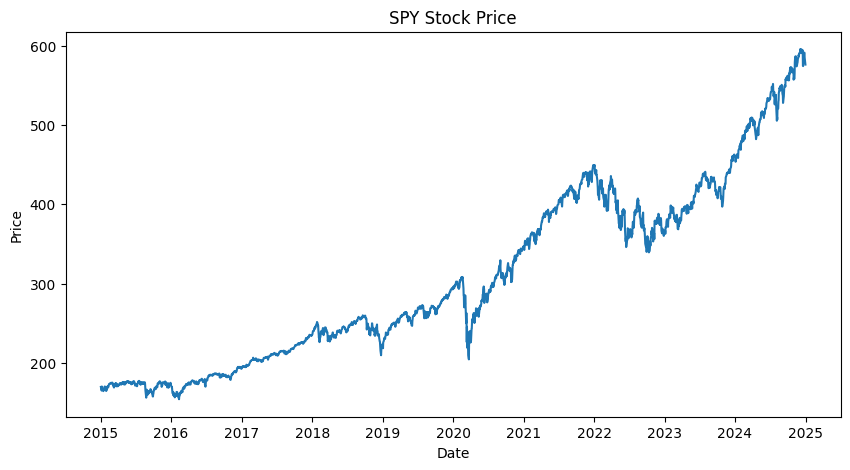

In [ ]:
#Making a plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(data.index,data['Close'])
plt.title('SPY Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [ ]:
#%change
data["Return"] = data["Close"].pct_change()

# Moving averages
data['MAvg5'] = data['Close'].rolling(window=5).mean()
data['MAvg20'] = data['Close'].rolling(window=20).mean()

In [ ]:
#Volatility over 10 days
data["Vola10"] = data["Return"].rolling(window=10).std()

#delta = difference

delta = data["Close"].diff()
gain = delta.clip(lower = 0)
loss = -delta.clip(upper = 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
data['RSI14'] = 100 - (100 / (1 + rs))

data[['Close', 'Return', 'Vola10', 'RSI14']].tail(15)

Price,Close,Return,Vola10,RSI14
Date,,,,
2024-12-10,590.665894,-0.003109,0.004105,72.194315
2024-12-11,595.232056,0.007731,0.004461,75.996051
2024-12-12,592.165161,-0.005152,0.004724,66.359813
2024-12-13,592.047546,-0.000199,0.004346,64.096012
2024-12-16,594.575562,0.004270,0.004509,64.735689
2024-12-17,592.125854,-0.004120,0.004744,55.908929
2024-12-18,574.478455,-0.029803,0.010153,36.646129
2024-12-19,574.302063,-0.000307,0.010190,31.070194
2024-12-20,581.200012,0.012011,0.011223,39.384419


In [ ]:
# Tomorrow's close, aligned with today's row
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

data[['Close', 'Return', 'MAvg5', 'MAvg20', 'RSI14', 'Target']].tail(10)

Price,Close,Return,MAvg5,MAvg20,RSI14,Target
Date,,,,,,
2024-12-17,592.125854,-0.004120,593.229236,589.576752,55.908929,0
2024-12-18,574.478455,-0.029803,589.078516,589.379797,36.646129,0
2024-12-19,574.302063,-0.000307,585.505896,589.164227,31.070194,1
2024-12-20,581.200012,0.012011,583.336389,589.138248,39.384419,1
2024-12-23,584.680359,0.005988,581.357349,589.196140,43.149018,1
2024-12-24,591.179077,0.011115,581.167993,589.479993,46.097898,1
2024-12-26,591.218445,0.000067,584.515991,589.612955,46.981931,0
2024-12-27,584.994995,-0.010526,586.654578,589.523914,40.972857,0
2024-12-30,578.319214,-0.011412,586.078418,588.918826,38.596004,0


In [ ]:
# Dropping rows with missing values
data_clean = data.dropna()

print(data.shape, "->", data_clean.shape)
#data_clean.head()

(2516, 11) -> (2497, 11)


In [ ]:
# Splitting the data
split_date = "2023-01-01"

train = data_clean[data_clean.index < split_date]
test = data_clean[data_clean.index >= split_date]

print("Train:", train.shape, train.index.min(), "to", train.index.max())
#print("Test:", test.shape, test.index.min(), "to", test.index.max())

Train: (1995, 11) 2015-01-30 00:00:00 to 2022-12-30 00:00:00


In [ ]:
# Selecting a set of features for testing and training

features = ['Return', 'MAvg5', 'MAvg20', 'Vola10', 'RSI14']

X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1995, 5) (1995,) (502, 5) (502,)


In [ ]:
#Building the model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("Model accuracy:", accuracy)

# Baseline: what if we just always guessed "up"?
baseline_accuracy = y_test.mean()  # fraction of days that were actually "up"
print("Always-up baseline accuracy:", baseline_accuracy)

Model accuracy: 0.5557768924302788
Always-up baseline accuracy: 0.5737051792828686


In [ ]:
# Building a confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[ 33 181]
 [ 42 246]]
              precision    recall  f1-score   support

           0       0.44      0.15      0.23       214
           1       0.58      0.85      0.69       288

    accuracy                           0.56       502
   macro avg       0.51      0.50      0.46       502
weighted avg       0.52      0.56      0.49       502



In [ ]:
#fixing class imbalance
model_balanced = LogisticRegression(class_weight='balanced')
model_balanced.fit(X_train, y_train)

predictions_balanced = model_balanced.predict(X_test)

print("Balanced model accuracy:", accuracy_score(y_test, predictions_balanced))
print(confusion_matrix(y_test, predictions_balanced))
print(classification_report(y_test, predictions_balanced))

Balanced model accuracy: 0.4203187250996016
[[203  11]
 [280   8]]
              precision    recall  f1-score   support

           0       0.42      0.95      0.58       214
           1       0.42      0.03      0.05       288

    accuracy                           0.42       502
   macro avg       0.42      0.49      0.32       502
weighted avg       0.42      0.42      0.28       502

